# Boxplot – einfach verstehen

> Quelle: [numiqo.de](https://numiqo.de/tutorial/boxplot)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Ein **Boxplot** (auch Box-Whisker-Plot) stellt in einer einzigen Grafik eine Vielzahl
von Informationen über eine metrische Variable dar:

| Element | Statistik | Bedeutung |
|---|---|---|
| **Linie in der Box** | Median (Q2) | 50 % der Werte liegen darunter |
| **Untere Boxkante** | Q1 (25. Perzentil) | 25 % der Werte liegen darunter |
| **Obere Boxkante** | Q3 (75. Perzentil) | 75 % der Werte liegen darunter |
| **Box selbst** | IQR = Q3 − Q1 | Bereich der mittleren 50 % |
| **Gestrichelte Linie** | Mittelwert | Durchschnitt |
| **Whisker (T-Linien)** | Q1 − 1,5×IQR bis Q3 + 1,5×IQR | Bereich ohne Ausreißer |
| **Punkte außerhalb** | Ausreißer | Werte außerhalb des 1,5×IQR-Bereichs |

> **Skalenniveau:** Metrische Variablen (Alter, Stromverbrauch, Temperatur, ...)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Aufbau des Boxplots – Schritt für Schritt

**Beispiel (numiqo):** Alter von Personen in einer Studie.
- Q1 = 31 Jahre → 25 % der Teilnehmenden sind jünger als 31
- Q3 = 63 Jahre → 25 % der Teilnehmenden sind älter als 63
- Median = 42 Jahre → die Hälfte ist jünger, die Hälfte älter als 42

**Whisker-Regel:**
- Oberer Whisker = letzter Wert ≤ Q3 + 1,5 × IQR
- Unterer Whisker = erster Wert ≥ Q1 − 1,5 × IQR
- Alle Punkte außerhalb dieser Grenzen = **Ausreißer**

In [8]:
# Beispieldaten: Alter (numiqo-Beispiel)
alter = pd.Series([22, 25, 28, 31, 33, 35, 38, 40, 42, 44,
                   47, 50, 53, 57, 60, 63, 67, 72, 85, 91])

q1  = alter.quantile(0.25)
q2  = alter.quantile(0.50)   # Median
q3  = alter.quantile(0.75)
iqr = q3 - q1
mw  = alter.mean()

whisker_unten = alter[alter >= q1 - 1.5 * iqr].min()
whisker_oben  = alter[alter <= q3 + 1.5 * iqr].max()
ausreisser    = alter[(alter < q1 - 1.5 * iqr) | (alter > q3 + 1.5 * iqr)]

print("Kennzahlen: Alter")
print(f"n:               {len(alter)}")
print(f"Minimum:         {alter.min()}")
print(f"Q1 (25%):        {q1}")
print(f"Median (Q2/50%): {q2}")
print(f"Mittelwert:      {mw:.1f}")
print(f"Q3 (75%):        {q3}")
print(f"Maximum:         {alter.max()}")
print(f"IQR:             {iqr}")
print(f"Whisker unten:   {whisker_unten}  (>= Q1 - 1.5*IQR = {q1-1.5*iqr:.1f})")
print(f"Whisker oben:    {whisker_oben}  (<= Q3 + 1.5*IQR = {q3+1.5*iqr:.1f})")
print(f"Ausreisser:      {list(ausreisser)} ({len(ausreisser)} Wert(e))")

Kennzahlen: Alter
n:               20
Minimum:         22
Q1 (25%):        34.5
Median (Q2/50%): 45.5
Mittelwert:      49.1
Q3 (75%):        60.75
Maximum:         91
IQR:             26.25
Whisker unten:   22  (>= Q1 - 1.5*IQR = -4.9)
Whisker oben:    91  (<= Q3 + 1.5*IQR = 100.1)
Ausreisser:      [] (0 Wert(e))


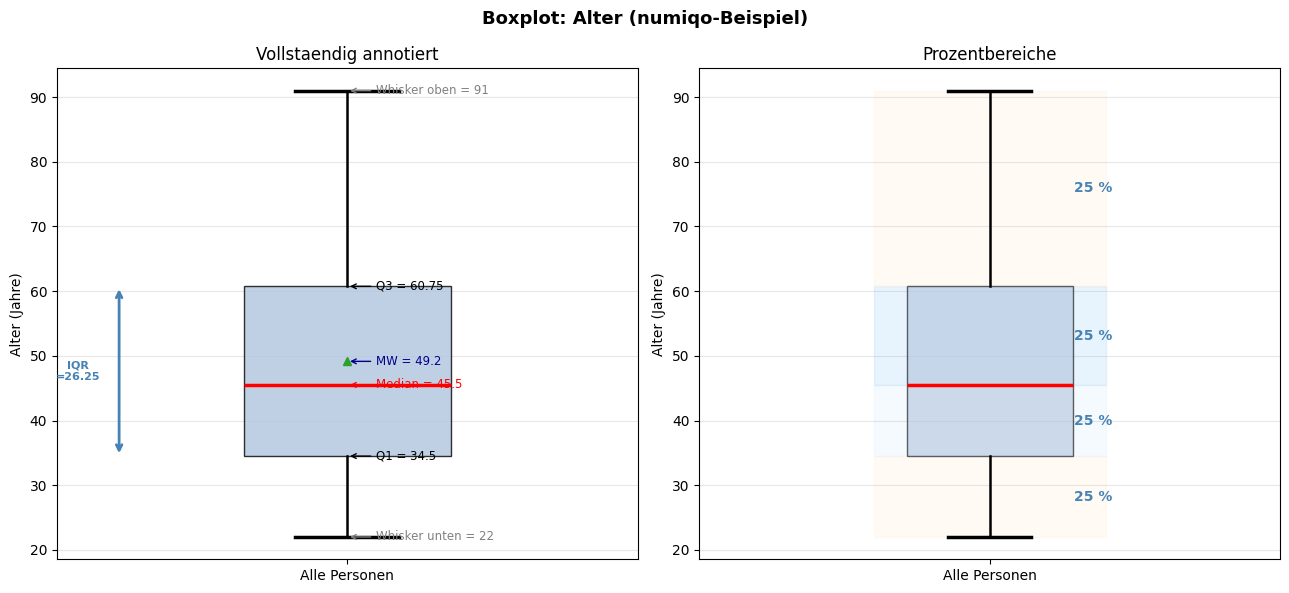

In [9]:
# Boxplot mit vollstaendigen Annotierungen
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Boxplot: Alter (numiqo-Beispiel)", fontsize=13, fontweight="bold")

# Links: annotierter Boxplot
bp = axes[0].boxplot(alter, patch_artist=True, vert=True,
                     widths=0.5,
                     boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                     medianprops=dict(color="red", linewidth=2.5),
                     meanprops=dict(linestyle="--", linewidth=2,
                                    color="darkblue"),
                     showmeans=True,
                     whiskerprops=dict(linewidth=1.8),
                     capprops=dict(linewidth=2.5),
                     flierprops=dict(marker="o", markerfacecolor="tomato",
                                     markersize=8, markeredgecolor="darkred"))

# Annotierungen
annotierungen = [
    (q3,              "Q3 = " + str(q3),        1.07, "black"),
    (q2,              "Median = " + str(q2),     1.07, "red"),
    (mw,              "MW = " + str(round(mw,1)),1.07, "darkblue"),
    (q1,              "Q1 = " + str(q1),         1.07, "black"),
    (whisker_oben,    "Whisker oben = " + str(whisker_oben), 1.07, "gray"),
    (whisker_unten,   "Whisker unten = " + str(whisker_unten), 1.07, "gray"),
]
for y_pos, label, x_txt, farbe in annotierungen:
    axes[0].annotate(label, xy=(1.0, y_pos), xytext=(x_txt, y_pos),
                     fontsize=8.5, color=farbe, va="center",
                     arrowprops=dict(arrowstyle="->", color=farbe, lw=1))

# IQR-Pfeil
axes[0].annotate("", xy=(0.45, q1), xytext=(0.45, q3),
                 arrowprops=dict(arrowstyle="<->", color="steelblue", lw=2))
iqr_label = "IQR\n=" + str(iqr)
axes[0].text(0.35, (q1+q3)/2, iqr_label, ha="center", va="center",
             fontsize=8, color="steelblue", fontweight="bold")

axes[0].set_title("Vollstaendig annotiert")
axes[0].set_ylabel("Alter (Jahre)")
axes[0].set_xticklabels(["Alle Personen"])
axes[0].set_xlim(0.3, 1.7)
axes[0].grid(axis="y", alpha=0.3)

# Rechts: Prozentbereiche visualisieren
axes[1].boxplot(alter, patch_artist=True, vert=True, widths=0.4,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.6),
                medianprops=dict(color="red", linewidth=2.5),
                whiskerprops=dict(linewidth=1.8),
                capprops=dict(linewidth=2.5),
                flierprops=dict(marker="o", markerfacecolor="tomato",
                                markersize=8))

bereiche = [
    (whisker_unten, q1, "#fff3e0", "25 %"),
    (q1,           q2, "#e3f2fd", "25 %"),
    (q2,           q3, "#bbdefb", "25 %"),
    (q3, whisker_oben, "#fff3e0", "25 %"),
]
for y_lo, y_hi, farbe, label in bereiche:
    axes[1].axhspan(y_lo, y_hi, xmin=0.3, xmax=0.7,
                    alpha=0.35, color=farbe)
    axes[1].text(1.25, (y_lo+y_hi)/2, label,
                 ha="center", va="center", fontsize=10, color="steelblue",
                 fontweight="bold")

axes[1].set_title("Prozentbereiche")
axes[1].set_ylabel("Alter (Jahre)")
axes[1].set_xticklabels(["Alle Personen"])
axes[1].set_xlim(0.3, 1.7)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Whisker und Ausreißer im Detail

**Whisker-Formel:**

$$\text{Whisker oben}  = \max\{x : x \leq Q3 + 1{,}5 \times IQR\}$$
$$\text{Whisker unten} = \min\{x : x \geq Q1 - 1{,}5 \times IQR\}$$

**Ausreißer** = alle Werte außerhalb dieser Grenzen → als einzelne Punkte dargestellt.

> Gibt es **keinen** Ausreißer, zeigt der Whisker den tatsächlichen **Minimal-
> bzw. Maximalwert** an.

Ohne Ausreisser
  Q1=46.3, Q3=54.9, IQR=8.6
  Grenzen: [33.3, 67.8]
  Ausreisser (1): [69.4]
Mit Ausreissern
  Q1=45.2, Q3=55.3, IQR=10.1
  Grenzen: [30.0, 70.5]
  Ausreisser (4): [4.0, 7.0, 92.0, 97.0]


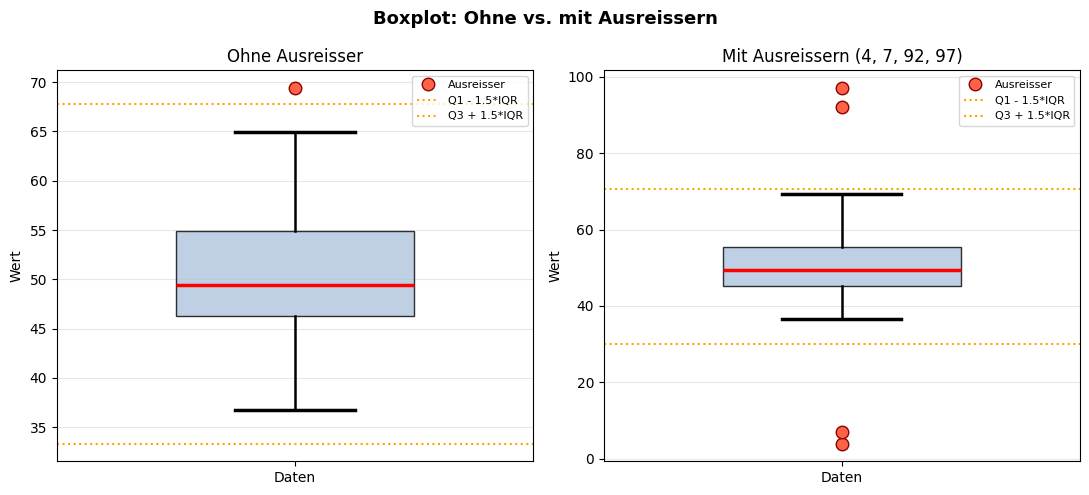

In [10]:
# Ausreisser-Erkennung und Visualisierung
np.random.seed(5)
daten_ohne = pd.Series(np.random.normal(50, 8, 40).clip(25, 75).round(1))
daten_mit  = pd.concat([daten_ohne,
                         pd.Series([4, 7, 92, 97])]).reset_index(drop=True)

def ausreisser_info(daten, name):
    q1_  = daten.quantile(0.25)
    q3_  = daten.quantile(0.75)
    iqr_ = q3_ - q1_
    grenze_u = q1_ - 1.5 * iqr_
    grenze_o = q3_ + 1.5 * iqr_
    ausrss   = daten[(daten < grenze_u) | (daten > grenze_o)]
    print(f"{name}")
    print(f"  Q1={q1_:.1f}, Q3={q3_:.1f}, IQR={iqr_:.1f}")
    print(f"  Grenzen: [{grenze_u:.1f}, {grenze_o:.1f}]")
    print(f"  Ausreisser ({len(ausrss)}): {sorted(ausrss.tolist())}")

ausreisser_info(daten_ohne, "Ohne Ausreisser")
ausreisser_info(daten_mit,  "Mit Ausreissern")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Boxplot: Ohne vs. mit Ausreissern", fontsize=13, fontweight="bold")

for ax, daten, titel in zip(axes,
                              [daten_ohne, daten_mit],
                              ["Ohne Ausreisser", "Mit Ausreissern (4, 7, 92, 97)"]):
    q1_ = daten.quantile(0.25)
    q3_ = daten.quantile(0.75)
    iqr_= q3_ - q1_
    bp  = ax.boxplot(daten, patch_artist=True, vert=True, widths=0.5,
                     boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                     medianprops=dict(color="red", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.8),
                     capprops=dict(linewidth=2.5),
                     flierprops=dict(marker="o", markerfacecolor="tomato",
                                     markersize=9, markeredgecolor="darkred",
                                     label="Ausreisser"))
    ax.axhline(q1_ - 1.5*iqr_, color="orange", linestyle=":", linewidth=1.5,
               label="Q1 - 1.5*IQR")
    ax.axhline(q3_ + 1.5*iqr_, color="orange", linestyle=":", linewidth=1.5,
               label="Q3 + 1.5*IQR")
    ax.set_title(titel)
    ax.set_ylabel("Wert")
    ax.set_xticklabels(["Daten"])
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Median und Mittelwert im Boxplot

Im Boxplot wird standardmäßig der **Median** als durchgezogene rote Linie angezeigt.
Oft wird zusätzlich der **Mittelwert** als gestrichelte Linie eingezeichnet.

**Was sagt die Lage von Median und Mittelwert über die Verteilung aus?**

| Lage | Verteilung |
|---|---|
| Median ≈ Mittelwert, Median mittig in der Box | Symmetrisch |
| Median < Mittelwert, Median näher an Q1 | Rechtsschiefe (positive Schiefe) |
| Median > Mittelwert, Median näher an Q3 | Linksschiefe (negative Schiefe) |

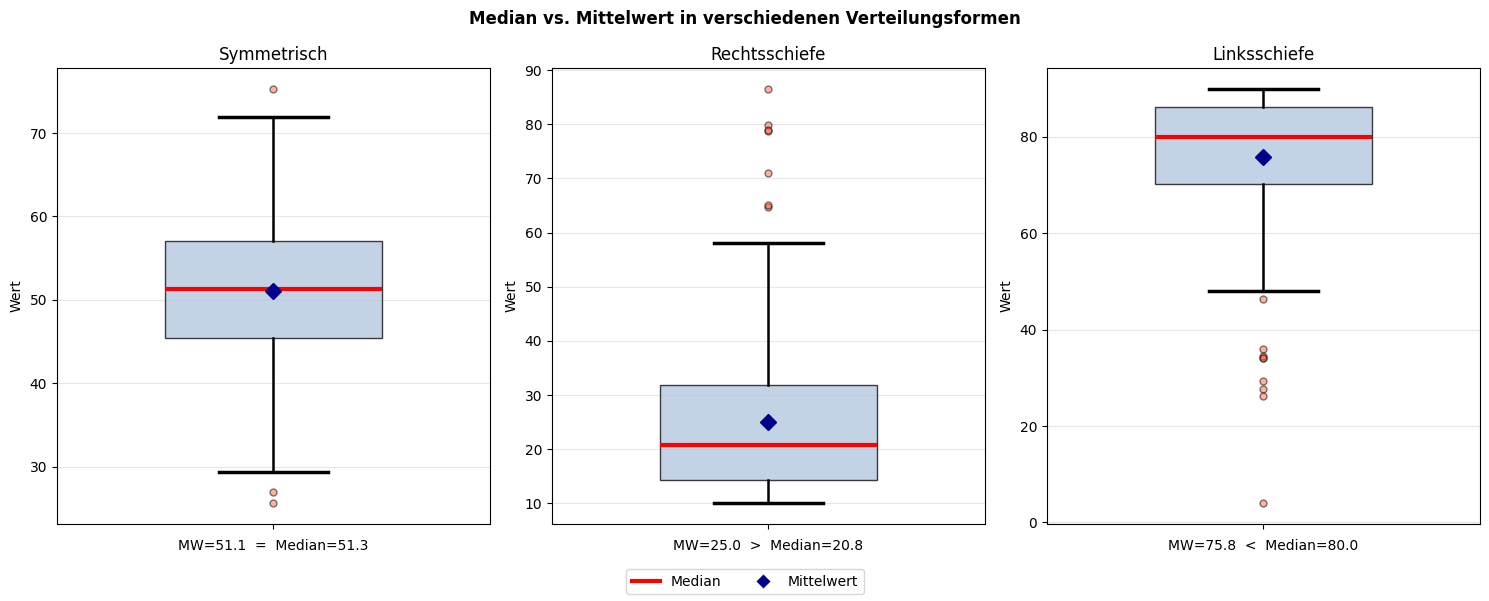

In [5]:
# Median vs. Mittelwert – drei Verteilungsformen
np.random.seed(1)
symmetrisch   = pd.Series(np.random.normal(50, 10, 200))
rechtsschief  = pd.Series(np.random.exponential(scale=15, size=200) + 10)
linksschief   = pd.Series(100 - np.random.exponential(scale=15, size=200) - 10)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Median vs. Mittelwert in verschiedenen Verteilungsformen",
             fontsize=12, fontweight="bold")

for ax, daten, titel in zip(
    axes,
    [symmetrisch, rechtsschief, linksschief],
    ["Symmetrisch", "Rechtsschiefe", "Linksschiefe"]
):
    mw_  = daten.mean()
    med_ = daten.median()

    bp = ax.boxplot(daten, patch_artist=True, vert=True, widths=0.5,
                    boxprops=dict(facecolor="lightsteelblue", alpha=0.75),
                    medianprops=dict(color="red", linewidth=3),
                    meanprops=dict(marker="D", markerfacecolor="darkblue",
                                   markersize=8, markeredgecolor="darkblue"),
                    showmeans=True,
                    whiskerprops=dict(linewidth=1.8),
                    capprops=dict(linewidth=2.5),
                    flierprops=dict(marker="o", markerfacecolor="tomato",
                                    markersize=5, alpha=0.5))

    ax.set_title(titel)
    ax.set_ylabel("Wert")
    ax.set_xticklabels([""])
    ax.grid(axis="y", alpha=0.3)

    diff = mw_ - med_
    pfeil = ">" if diff > 1 else ("<" if diff < -1 else "=")
    ax.set_xlabel(f"MW={mw_:.1f}  {pfeil}  Median={med_:.1f}", fontsize=10)

# Legende
linie_med = mlines.Line2D([], [], color="red", linewidth=3, label="Median")
punkt_mw  = mlines.Line2D([], [], marker="D", color="w",
                           markerfacecolor="darkblue", markersize=8, label="Mittelwert")
fig.legend(handles=[linie_med, punkt_mw], loc="lower center",
           ncol=2, fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 4. Boxplot für Gruppenvergleiche

Boxplots werden sehr oft eingesetzt, um **mehrere Gruppen** gleichzeitig zu
vergleichen. Das entspricht genau dem numiqo-Beispiel, wo der **Sturzort**
dem **Alter** der gestürzten Personen gegenübergestellt wird.

**Was lässt sich im Gruppenvergleich ablesen?**
- Unterscheiden sich die **Mediane** zwischen den Gruppen?
- Ist die **Streuung** (Boxhöhe, Whiskerlänge) in den Gruppen ähnlich?
- Gibt es in manchen Gruppen mehr **Ausreißer**?
- Ist die Verteilung **symmetrisch** oder **schief**?

Kennzahlen je Sturzort
  Zimmer         : n=40, MW=69.4, Median=69.2, SD=11.4, IQR=15.2
  Gang           : n=40, MW=67.6, Median=68.4, SD=13.5, IQR=17.9
  Bad            : n=40, MW=75.1, Median=74.7, SD=7.8, IQR=7.0
  Aussenbereich  : n=40, MW=60.5, Median=64.3, SD=15.7, IQR=23.2


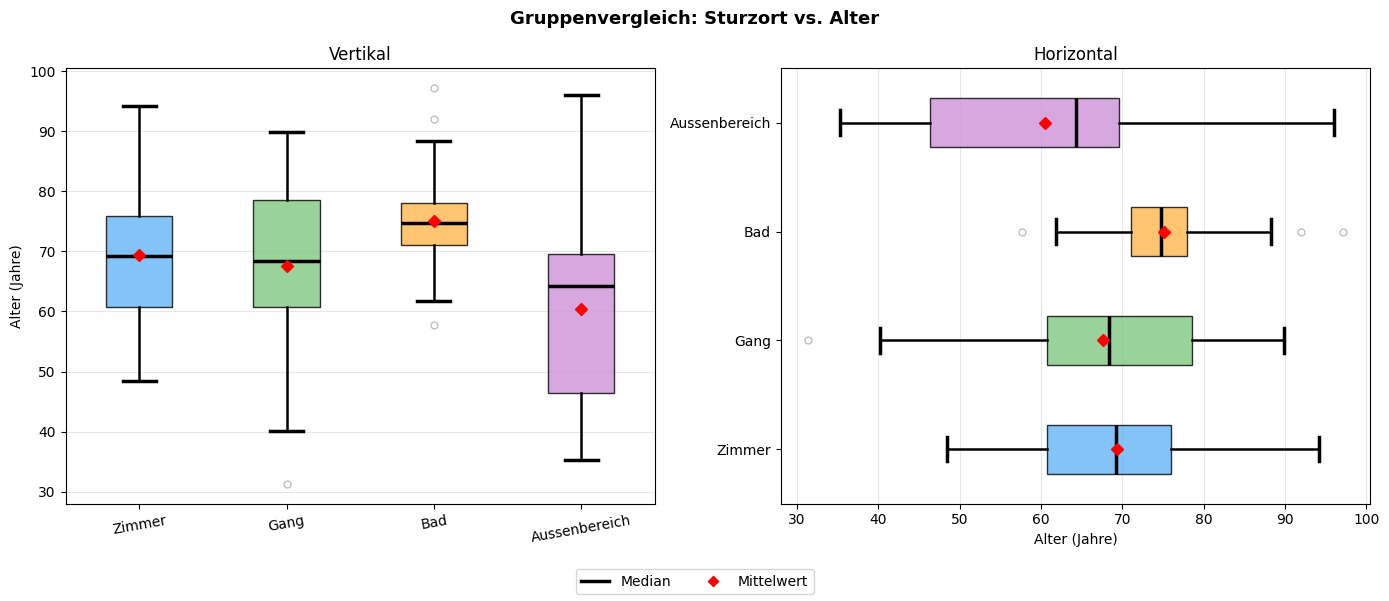

In [11]:
# Gruppenvergleich – Sturzort vs. Alter (numiqo-Beispiel)
np.random.seed(42)
n_pro_gruppe = 40
sturzorte    = ["Zimmer", "Gang", "Bad", "Aussenbereich"]
alter_daten  = {
    "Zimmer":       np.random.normal(72, 12, n_pro_gruppe).clip(18, 99),
    "Gang":         np.random.normal(68, 14, n_pro_gruppe).clip(18, 99),
    "Bad":          np.random.normal(75,  9, n_pro_gruppe).clip(18, 99),
    "Aussenbereich":np.random.normal(61, 16, n_pro_gruppe).clip(18, 99),
}

print("Kennzahlen je Sturzort")
for ort, werte in alter_daten.items():
    s = pd.Series(werte)
    print(f"  {ort:<15}: n={len(s)}, MW={s.mean():.1f}, "
          f"Median={s.median():.1f}, SD={s.std():.1f}, "
          f"IQR={s.quantile(0.75)-s.quantile(0.25):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Gruppenvergleich: Sturzort vs. Alter", fontsize=13, fontweight="bold")

farben_gruppen = ["#64B5F6", "#81C784", "#FFB74D", "#CE93D8"]

# Vertikal
bp1 = axes[0].boxplot(list(alter_daten.values()),
                       patch_artist=True,
                       medianprops=dict(color="black", linewidth=2.5),
                       meanprops=dict(marker="D", markerfacecolor="red",
                                      markersize=6, markeredgecolor="red"),
                       showmeans=True,
                       whiskerprops=dict(linewidth=1.8),
                       capprops=dict(linewidth=2.5),
                       flierprops=dict(marker="o", markersize=5,
                                       alpha=0.5, markeredgecolor="gray"))
for patch, farbe in zip(bp1["boxes"], farben_gruppen):
    patch.set_facecolor(farbe)
    patch.set_alpha(0.8)

axes[0].set_title("Vertikal")
axes[0].set_ylabel("Alter (Jahre)")
axes[0].set_xticks(range(1, len(sturzorte)+1))
axes[0].set_xticklabels(sturzorte, rotation=10)
axes[0].grid(axis="y", alpha=0.3)

# Horizontal
bp2 = axes[1].boxplot(list(alter_daten.values()),
                       patch_artist=True, vert=False,
                       medianprops=dict(color="black", linewidth=2.5),
                       meanprops=dict(marker="D", markerfacecolor="red",
                                      markersize=6, markeredgecolor="red"),
                       showmeans=True,
                       whiskerprops=dict(linewidth=1.8),
                       capprops=dict(linewidth=2.5),
                       flierprops=dict(marker="o", markersize=5,
                                       alpha=0.5, markeredgecolor="gray"))
for patch, farbe in zip(bp2["boxes"], farben_gruppen):
    patch.set_facecolor(farbe)
    patch.set_alpha(0.8)

axes[1].set_title("Horizontal")
axes[1].set_xlabel("Alter (Jahre)")
axes[1].set_yticks(range(1, len(sturzorte)+1))
axes[1].set_yticklabels(sturzorte)
axes[1].grid(axis="x", alpha=0.3)

# Gemeinsame Legende
linie_med = mlines.Line2D([], [], color="black", linewidth=2.5, label="Median")
punkt_mw  = mlines.Line2D([], [], marker="D", color="w",
                           markerfacecolor="red", markersize=7, label="Mittelwert")
fig.legend(handles=[linie_med, punkt_mw], loc="lower center",
           ncol=2, fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 5. Boxplot mit Rohdaten (Jitter-Plot)

Eine moderne Ergänzung zum Boxplot ist die Darstellung der **Rohdaten** als
überlagerte Punkte (Jitter). Das gibt einen vollständigeren Eindruck der Verteilung –
besonders wichtig bei kleinen Stichproben.

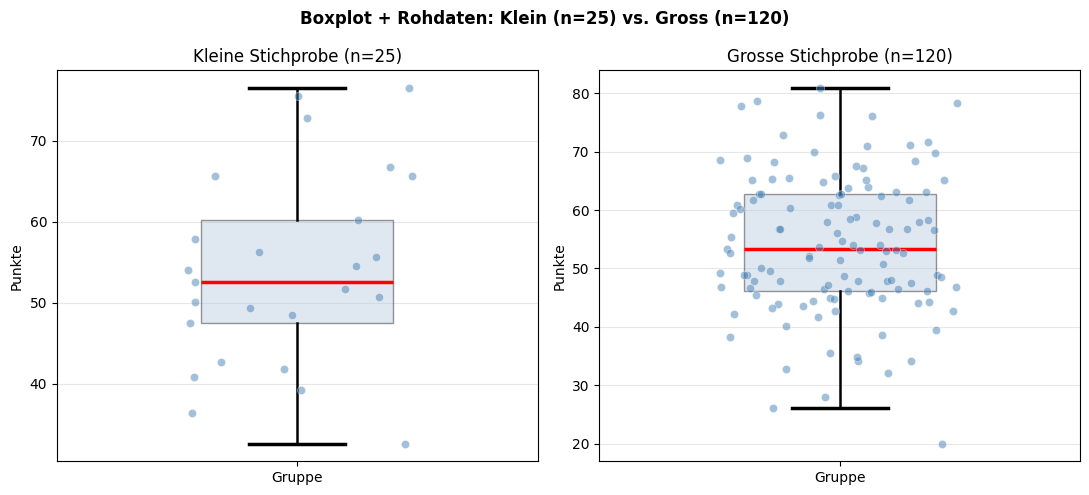

In [7]:
# Boxplot mit ueberlagerten Rohdaten (Jitter)
np.random.seed(3)
kleine_gruppe = pd.Series(np.random.normal(55, 12, 25).clip(20, 90).round(1))
grosse_gruppe = pd.Series(np.random.normal(55, 12, 120).clip(20, 90).round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Boxplot + Rohdaten: Klein (n=25) vs. Gross (n=120)",
             fontsize=12, fontweight="bold")

for ax, daten, titel in zip(
    axes,
    [kleine_gruppe, grosse_gruppe],
    ["Kleine Stichprobe (n=25)", "Grosse Stichprobe (n=120)"]
):
    ax.boxplot(daten, patch_artist=True, widths=0.4,
               boxprops=dict(facecolor="lightsteelblue", alpha=0.4),
               medianprops=dict(color="red", linewidth=2.5),
               whiskerprops=dict(linewidth=1.8),
               capprops=dict(linewidth=2.5),
               flierprops=dict(marker="", markersize=0))  # Ausreisser separat

    # Jitter
    x_jitter = np.random.uniform(0.75, 1.25, len(daten))
    ax.scatter(x_jitter, daten, color="steelblue", alpha=0.5,
               s=35, edgecolors="white", linewidths=0.5, zorder=3)

    ax.set_title(titel)
    ax.set_ylabel("Punkte")
    ax.set_xticklabels(["Gruppe"])
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Zusammenfassung

```
Boxplot – Aufbau und Interpretation
│
├── BESTANDTEILE
│   ├── Box          = IQR  (mittlere 50 % der Daten)
│   ├── Linie        = Median  (rote durchgezogene Linie)
│   ├── Raute/Strich = Mittelwert  (gestrichelt/Punkt)
│   ├── Whisker      = bis Q1-1.5*IQR bzw. Q3+1.5*IQR
│   └── Punkte       = Ausreisser  (ausserhalb der Whisker)
│
├── QUARTILE & PROZENTE
│   ├── Unter Q1:          25 % der Daten
│   ├── Q1 bis Median:     25 % der Daten
│   ├── Median bis Q3:     25 % der Daten
│   └── Ueber Q3:          25 % der Daten
│
├── AUSREISSER-REGEL
│   ├── Grenze oben:  Q3 + 1.5 * IQR
│   └── Grenze unten: Q1 - 1.5 * IQR
│
├── SCHIEFE ABLESEN
│   ├── Median mittig, MW ≈ Median   → symmetrisch
│   ├── Median naeher an Q1, MW > Median → rechtsschiefe
│   └── Median naeher an Q3, MW < Median → linksschiefe
│
└── TYPISCHER EINSATZ
    ├── Einzelne Variable: Verteilung beschreiben
    ├── Gruppenvergleich:  Mediane und Streuung vergleichen
    └── + Jitter:          Rohdaten bei kleinen Stichproben zeigen
```

| Python-Parameter | Bedeutung |
|---|---|
| `patch_artist=True` | Farbige Box |
| `medianprops` | Median-Linie stylen |
| `showmeans=True` | Mittelwert einzeichnen |
| `meanprops` | Mittelwert-Symbol stylen |
| `flierprops` | Ausreisser-Punkte stylen |
| `vert=False` | Horizontaler Boxplot |

---
Quelle: [numiqo.de/tutorial/boxplot](https://numiqo.de/tutorial/boxplot)